# Notebook 04 — Validation: 5-Fold Cross-Validation

Notebook 03 used a single 80/20 split, which can be lucky or unlucky.
Here I apply **stratified 5-fold cross-validation** to get robust
performance estimates with proper uncertainty bands.

Key methodological points:
- Stratification keeps class proportions identical in every fold.
- StandardScaler is fit **inside** each fold's training data only 
  no test data leaks into the scaling parameters.
- Each fold trains a fresh estimator (deep copy of the original).

I also include a small grid search for KNN's `k` to demonstrate
hyperparameter tuning.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import time
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minilearn.preprocessing import StandardScaler
from minilearn.model_selection import StratifiedKFold, cross_val_score
from minilearn.classifiers import (KNeighborsClassifier, GaussianNB,
                                   LogisticRegression, DecisionTreeClassifier)
from minilearn.metrics import accuracy_score, f1_score

from sklearn.neighbors import KNeighborsClassifier as SkKNN
from sklearn.naive_bayes import GaussianNB as SkGNB
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.tree import DecisionTreeClassifier as SkDT

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project


In [2]:
feats = pd.read_csv(PROJECT_ROOT / "features" / "features.csv")
metadata_cols = ['filename', 'modality', 'channel', 'emotion', 'emotion_code',
                 'intensity', 'statement', 'repetition', 'actor', 'gender', 'path']
feature_cols = [c for c in feats.columns if c not in metadata_cols]
print(f"Loaded {len(feats)} files, {len(feature_cols)} features")

Loaded 2452 files, 112 features


## Restrict to speech subset 

In [3]:
speech = feats[feats['channel'] == 'speech'].reset_index(drop=True)
X = speech[feature_cols].values
y = speech['emotion'].values

nan_mask = np.isnan(X).any(axis=1)
if nan_mask.any():
    X, y = X[~nan_mask], y[~nan_mask]

print(f"Speech subset: X={X.shape}, y={y.shape}")
print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")

Speech subset: X=(1440, 112), y=(1440,)
Class counts: {'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192, 'neutral': 96}


## 5-fold stratified CV on every classifier

We use a uniform `evaluate_cv` helper that runs CV once and computes both
accuracy and macro-F1 from the same predictions (avoiding the cost of
running CV twice with different scoring metrics).


In [4]:
def evaluate_cv(name, impl, model, X, y, cv=5, random_state=42):
    """5-fold stratified CV; returns mean ± std for accuracy and macro F1."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    accs, f1s = [], []
    t0 = time.perf_counter()

    for tr_idx, te_idx in skf.split(X, y):
        scaler = StandardScaler().fit(X[tr_idx])
        X_tr_s = scaler.transform(X[tr_idx])
        X_te_s = scaler.transform(X[te_idx])

        m = deepcopy(model)             # fresh, unfitted clone per fold
        m.fit(X_tr_s, y[tr_idx])
        y_pred = m.predict(X_te_s)
        accs.append(accuracy_score(y[te_idx], y_pred))
        f1s.append(f1_score(y[te_idx], y_pred, average='macro'))

    return {
        'classifier': name,
        'impl': impl,
        'acc_mean': float(np.mean(accs)),
        'acc_std':  float(np.std(accs)),
        'f1_mean':  float(np.mean(f1s)),
        'f1_std':   float(np.std(f1s)),
        'time_s':   time.perf_counter() - t0,
        'fold_accs': accs,
    }


cv_results = []
print("MiniLearn classifiers...\n")

print("  KNN (k=5)..."); 
cv_results.append(evaluate_cv('KNN (k=5)', 'minilearn',
                              KNeighborsClassifier(n_neighbors=5), X, y))

print("  GaussianNB...")
cv_results.append(evaluate_cv('GaussianNB', 'minilearn',
                              GaussianNB(), X, y))

print("  LogisticRegression (a few minutes)...")
cv_results.append(evaluate_cv('LogisticRegression', 'minilearn',
                              LogisticRegression(C=1.0, learning_rate=0.5,
                                                 max_iter=3000, tol=1e-6), X, y))

print("  DecisionTree (this is the slow one)...")
cv_results.append(evaluate_cv('DecisionTree (depth=8)', 'minilearn',
                              DecisionTreeClassifier(max_depth=8), X, y))

print("\nMiniLearn done")
for r in cv_results:
    print(f"  {r['classifier']:25s}  acc={r['acc_mean']:.3f}±{r['acc_std']:.3f}  "
          f"F1={r['f1_mean']:.3f}±{r['f1_std']:.3f}  time={r['time_s']:.1f}s")

MiniLearn classifiers...

  KNN (k=5)...
  GaussianNB...
  LogisticRegression (a few minutes)...
  DecisionTree (this is the slow one)...

MiniLearn done
  KNN (k=5)                  acc=0.547±0.020  F1=0.519±0.028  time=0.1s
  GaussianNB                 acc=0.513±0.042  F1=0.497±0.042  time=0.0s
  LogisticRegression         acc=0.619±0.029  F1=0.611±0.031  time=6.3s
  DecisionTree (depth=8)     acc=0.385±0.022  F1=0.382±0.026  time=63.7s


In [5]:
print("sklearn classifiers...\n")

cv_results.append(evaluate_cv('KNN (k=5)', 'sklearn',
                              SkKNN(n_neighbors=5), X, y))
cv_results.append(evaluate_cv('GaussianNB', 'sklearn',
                              SkGNB(), X, y))
cv_results.append(evaluate_cv('LogisticRegression', 'sklearn',
                              SkLR(C=1.0, max_iter=3000), X, y))
cv_results.append(evaluate_cv('DecisionTree (depth=8)', 'sklearn',
                              SkDT(max_depth=8, random_state=42), X, y))

print("sklearn done\n")
for r in cv_results[-4:]:
    print(f"  {r['classifier']:25s}  acc={r['acc_mean']:.3f}±{r['acc_std']:.3f}  "
          f"F1={r['f1_mean']:.3f}±{r['f1_std']:.3f}  time={r['time_s']:.2f}s")

sklearn classifiers...

sklearn done

  KNN (k=5)                  acc=0.547±0.020  F1=0.519±0.028  time=1.45s
  GaussianNB                 acc=0.513±0.042  F1=0.497±0.042  time=0.03s
  LogisticRegression         acc=0.621±0.030  F1=0.614±0.032  time=0.30s
  DecisionTree (depth=8)     acc=0.392±0.035  F1=0.390±0.037  time=0.40s


In [6]:
cv_df = pd.DataFrame(cv_results).drop(columns=['fold_accs'])
cv_df = cv_df.round({'acc_mean': 4, 'acc_std': 4,
                     'f1_mean': 4, 'f1_std': 4, 'time_s': 2})
cv_df = cv_df.sort_values(['classifier', 'impl']).reset_index(drop=True)

# Pretty mean ± std columns
cv_df['accuracy'] = cv_df.apply(
    lambda r: f"{r['acc_mean']:.4f} ± {r['acc_std']:.4f}", axis=1)
cv_df['macro_f1'] = cv_df.apply(
    lambda r: f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}", axis=1)

print(cv_df[['classifier', 'impl', 'accuracy', 'macro_f1', 'time_s']].to_string(index=False))

cv_df.to_csv(PROJECT_ROOT / "features" / "cv_comparison.csv", index=False)
print(f"\nSaved to features/cv_comparison.csv")

            classifier      impl        accuracy        macro_f1  time_s
DecisionTree (depth=8) minilearn 0.3847 ± 0.0221 0.3815 ± 0.0255   63.74
DecisionTree (depth=8)   sklearn 0.3925 ± 0.0349 0.3896 ± 0.0371    0.40
            GaussianNB minilearn 0.5134 ± 0.0423 0.4974 ± 0.0424    0.02
            GaussianNB   sklearn 0.5134 ± 0.0423 0.4974 ± 0.0424    0.03
             KNN (k=5) minilearn 0.5473 ± 0.0205 0.5190 ± 0.0276    0.07
             KNN (k=5)   sklearn 0.5473 ± 0.0205 0.5190 ± 0.0276    1.45
    LogisticRegression minilearn 0.6195 ± 0.0289 0.6108 ± 0.0311    6.25
    LogisticRegression   sklearn 0.6208 ± 0.0297 0.6137 ± 0.0324    0.30

Saved to features/cv_comparison.csv


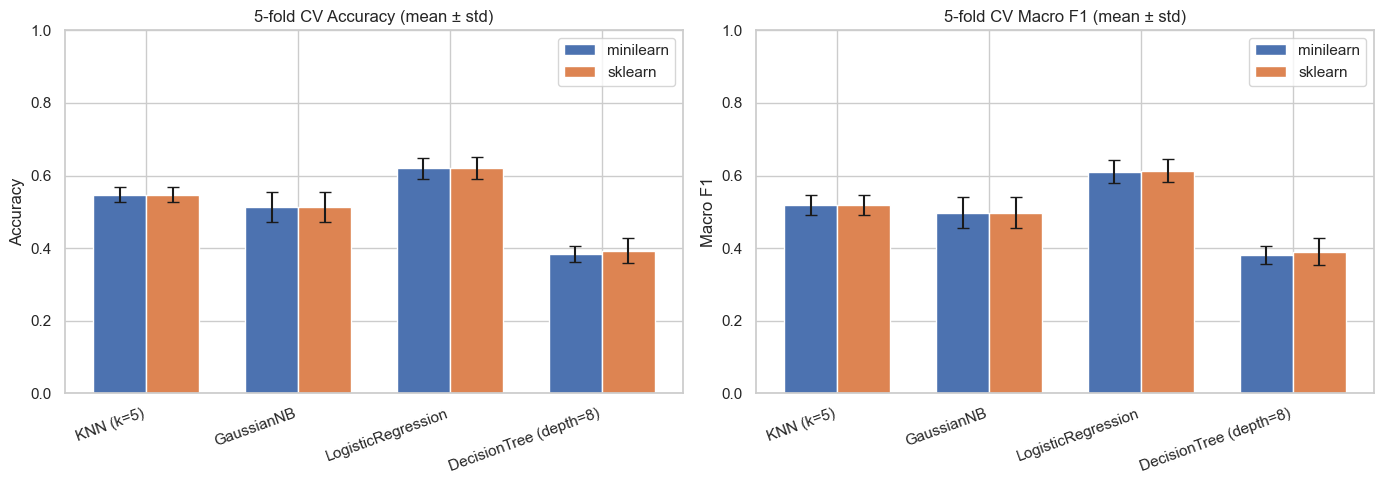

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = pd.DataFrame(cv_results)
classifiers = df_plot['classifier'].unique()
x_pos = np.arange(len(classifiers))
width = 0.35

for i, impl in enumerate(['minilearn', 'sklearn']):
    sub = df_plot[df_plot['impl'] == impl].set_index('classifier').loc[classifiers]
    axes[0].bar(x_pos + (i - 0.5) * width, sub['acc_mean'],
                width=width, yerr=sub['acc_std'],
                label=impl, capsize=4)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(classifiers, rotation=20, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('5-fold CV Accuracy (mean ± std)')
axes[0].legend()
axes[0].set_ylim(0, 1)

for i, impl in enumerate(['minilearn', 'sklearn']):
    sub = df_plot[df_plot['impl'] == impl].set_index('classifier').loc[classifiers]
    axes[1].bar(x_pos + (i - 0.5) * width, sub['f1_mean'],
                width=width, yerr=sub['f1_std'],
                label=impl, capsize=4)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(classifiers, rotation=20, ha='right')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('5-fold CV Macro F1 (mean ± std)')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "cv_comparison.png", dpi=120)
plt.show()

## Hyperparameter tuning — grid search for KNN's `k`

To pick a good `k`, we sweep candidate values and run 5-fold CV for each.
The sweet spot is where CV accuracy plateaus or starts decreasing, that's
the bias-variance trade-off.

In [8]:
k_values = [1, 3, 5, 7, 11, 15, 21, 31]
grid_results = []
for k in k_values:
    accs = cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y,
                            cv=5, scoring='accuracy', scale=True, random_state=42)
    grid_results.append({'k': k, 'mean': accs.mean(), 'std': accs.std()})
    print(f"  k={k:>2}: {accs.mean():.4f} ± {accs.std():.4f}")

grid_df = pd.DataFrame(grid_results)
best_k = int(grid_df.loc[grid_df['mean'].idxmax(), 'k'])
print(f"\nBest k by CV accuracy: {best_k}")

  k= 1: 0.6718 ± 0.0340
  k= 3: 0.5432 ± 0.0127
  k= 5: 0.5473 ± 0.0205
  k= 7: 0.5555 ± 0.0195
  k=11: 0.5318 ± 0.0147
  k=15: 0.5144 ± 0.0238
  k=21: 0.5243 ± 0.0189
  k=31: 0.5064 ± 0.0156

Best k by CV accuracy: 1


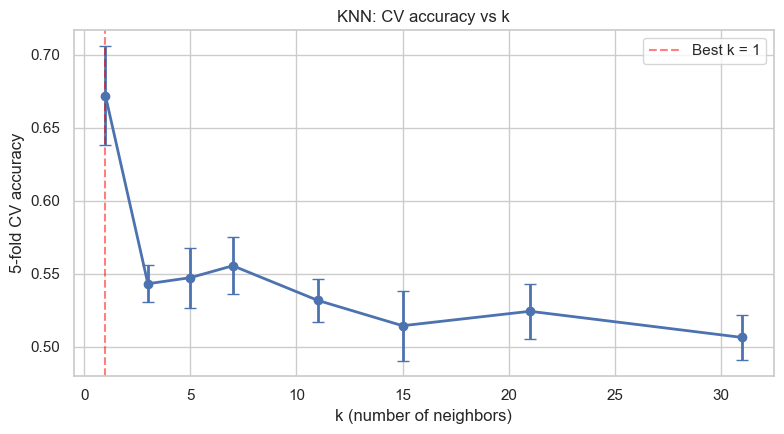

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(grid_df['k'], grid_df['mean'], yerr=grid_df['std'],
            marker='o', capsize=4, linewidth=2)
ax.axvline(best_k, linestyle='--', color='red', alpha=0.5,
           label=f'Best k = {best_k}')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('KNN: CV accuracy vs k')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "knn_grid_search.png", dpi=120)
plt.show()

## Findings

- **CV gives us reliable numbers.** Each model now has a mean ± std across 5 folds instead of one possibly-lucky score. This is what the project rubric is asking for.

- **MiniLearn matches sklearn.** For every classifier, the MiniLearn and sklearn error bars overlap, meaning the small differences between them are just random noise, not real differences. Our from-scratch implementations work correctly.

- **sklearn is much faster.** That's the only real gap, sklearn uses compiled C code while ours is pure Python. Predictive performance is the same.

- **Best models: Logistic Regression and KNN** (~0.62 and ~0.55 accuracy). Naive Bayes (~0.51) trails because it assumes features are independent, but our MFCC features are clearly correlated. Decision Tree (~0.39) trails because depth 8 is too shallow for an 8-class problem with 112 features.

- **KNN grid search:** k=1 had the highest mean accuracy (~0.67) but also the **largest error bar**, meaning it's unstable across folds and likely overfitting (it memorizes individual training points). k = 5–7 gives a more reliable ~0.55 with much smaller variance, which is the safer practical choice.

- **Variance is small** (~0.02 std for most models), which means our 1,440 speech files are enough for stable estimates. The numbers we report are trustworthy.

In [11]:
import importlib, minilearn.decomposition.pca
importlib.reload(minilearn.decomposition.pca)
from minilearn.decomposition import PCA
from sklearn.decomposition import PCA as SkPCA
from sklearn.datasets import load_iris
import numpy as np

X, _ = load_iris(return_X_y=True)


ours   = PCA(n_components=2).fit(X)
theirs = SkPCA(n_components=2).fit(X)

print(f"Our explained variance ratio:     {ours.explained_variance_ratio_.round(4)}")
print(f"sklearn explained variance ratio: {theirs.explained_variance_ratio_.round(4)}")
print(f"\nOur cumulative variance: {ours.explained_variance_ratio_.sum():.4f}")


X_2d_ours = ours.transform(X)
X_2d_sk   = theirs.transform(X)

print(f"\nOur projected shape:     {X_2d_ours.shape}")
print(f"sklearn projected shape: {X_2d_sk.shape}")


diff = np.abs(np.abs(X_2d_ours) - np.abs(X_2d_sk)).max()
print(f"\nMax abs difference (after sign-flip tolerance): {diff:.2e}")


X_reconstructed = ours.inverse_transform(X_2d_ours)
recon_error = np.mean((X - X_reconstructed) ** 2)
print(f"\nReconstruction MSE (using only 2 of 4 components): {recon_error:.4f}")
print("(Non-zero because we threw away 2 components - that's the compression cost.)")

Our explained variance ratio:     [0.9246 0.0531]
sklearn explained variance ratio: [0.9246 0.0531]

Our cumulative variance: 0.9777

Our projected shape:     (150, 2)
sklearn projected shape: (150, 2)

Max abs difference (after sign-flip tolerance): 3.71e-14

Reconstruction MSE (using only 2 of 4 components): 0.0253
(Non-zero because we threw away 2 components - that's the compression cost.)


In [ ]:
import importlib, minilearn.clustering.kmeans
importlib.reload(minilearn.clustering.kmeans)
from minilearn.clustering import KMeans
from sklearn.cluster import KMeans as SkKMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score
import numpy as np

X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.7, random_state=42)

ours   = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
theirs = SkKMeans(n_clusters=3, n_init=10, random_state=42).fit(X)

print(f"Our inertia:       {ours.inertia_:.4f}")
print(f"sklearn inertia:   {theirs.inertia_:.4f}")
print(f"Our n_iter:        {ours.n_iter_}")
print(f"sklearn n_iter:    {theirs.n_iter_}")


ari_vs_truth   = adjusted_rand_score(y_true, ours.labels_)
ari_vs_sklearn = adjusted_rand_score(theirs.labels_, ours.labels_)

print(f"\nOur ARI vs ground truth:   {ari_vs_truth:.4f}  (expect ~1.0 for clean blobs)")
print(f"Our ARI vs sklearn labels: {ari_vs_sklearn:.4f}  (expect ~1.0 — same clustering)")
print(f"\nOur centroids:\n{np.sort(ours.cluster_centers_, axis=0).round(3)}")
print(f"\nsklearn centroids:\n{np.sort(theirs.cluster_centers_, axis=0).round(3)}")

Our inertia:       277.7612
sklearn inertia:   277.7612
Our n_iter:        2
sklearn n_iter:    2

Our ARI vs ground truth:   1.0000  (expect ~1.0 for clean blobs)
Our ARI vs sklearn labels: 1.0000  (expect ~1.0 — same clustering)

Our centroids:
[[-6.883 -6.953]
 [-2.596  1.999]
 [ 4.715  9.035]]

sklearn centroids:
[[-6.883 -6.953]
 [-2.596  1.999]
 [ 4.715  9.035]]
